# F02_domains.ipynb
Figure 2: domain plots.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pyproj
import importlib
import sys
import rioxarray as rxr
from pathlib import Path
import xarray as xr
import contextily as ctx
from rasterio.features import shapes
from shapely.geometry import shape
from affine import Affine
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch, Rectangle, Ellipse, ConnectionPatch
from matplotlib.lines import Line2D
import matplotlib.image as mpimg
from pyproj import Geod


# gets rid of a lot of annoying warnings, we know there are NaNs (might want to remove this to double check)
import warnings
warnings.filterwarnings("ignore")


In [2]:
sys.path.insert(1, '../scripts/')

In [3]:
import metadata as metadata


# Functions

In [4]:
def tif_to_shape(mask_da):
    """
    Converts a boolean xarray to a geopandas shape.
    """
  # Boolean mask (or 0/1 mask)
    mask = mask_da.values.astype(np.uint8)

    # Build affine transform from xarray coordinates
    x = mask_da.x.values
    y = mask_da.y.values

    dx = np.abs(x[1] - x[0])
    dy = np.abs(y[1] - y[0])

    transform = Affine(
        dx, 0, x.min() - dx/2,
        0, -dy, y.max() + dy/2
    )

    # Polygonize
    geoms = [
        shape(geom)
        for geom, value in shapes(mask, mask=mask.astype(bool), transform=transform)
        if value == 1
    ]

    gdf = gpd.GeoDataFrame(
        geometry=geoms,
        crs=mask_da.rio.crs
    )

    # Merge all polygons into one watershed polygon
    gdf = gdf.dissolve()  

    return gdf


def sm_geog_curvilinear_to_rectilinear(ds,
                                       var = 'VEG',
                                       proj_string = '+proj=lcc +lat_1=30.0 +lat_2=50.0 +lat_0=39.100006 +lon_0=-97.9 +a=6370000 +b=6370000 +type=crs'):
    p = pyproj.Proj(proj_string)
    proj_x,proj_y = p(ds.XLONG.values,ds.XLAT.values,inverse = False)

    ## convert 2D lat/lon to 1D for rio reprojection and clipping ##
    lon_2v = proj_x[int(ds.XLAT.shape[0]/2),:]
    lat_2v = proj_y[:,int(ds.XLAT.shape[1]/2)]

    da = xr.DataArray(
    data = ds[var].values,
    dims = ["y","x"],
    coords = dict(
        y = (["y"], lat_2v),
        x = (["x"], lon_2v),
    )
    )
    da.name = var
    da = da.rio.write_crs(proj_string, inplace=False)
    return da

def veg_to_bins(da):
    ds = da.to_dataset()
    ## vegetation mapping ##
    ds['VEG'] = ds.VEG.astype(int)
    conditions  = [ (ds.VEG == 1) | (ds.VEG == 2) | (ds.VEG == 3) | (ds.VEG == 4) | (ds.VEG == 5), # forest
               (ds.VEG == 6) | (ds.VEG == 7) | (ds.VEG == 8) | (ds.VEG == 9) | (ds.VEG == 10) | (ds.VEG == 11), # shrub
               (ds.VEG == 12) | (ds.VEG == 13) | (ds.VEG == 14) | (ds.VEG == 15) | (ds.VEG == 16) | (ds.VEG == 17), # grass
               (ds.VEG == 18),  # bare
               (ds.VEG == 19) | (ds.VEG == 20) | (ds.VEG == 24), # water
               (ds.VEG == 21) | (ds.VEG == 22) | (ds.VEG == 23), # human
              ]
              
    choices     = [1, # forest
               2, # shrub
               3, # grass
               4, # bare
               5, # water
               6 # human
              ]
    dir_array = np.select(conditions, choices, default=np.nan)
    ds['veg_bin'] = xr.DataArray(data = dir_array,dims = ["y","x"])
    ds['veg_bin'] = ds.veg_bin.astype(int)
    return ds,choices




def terrain_no_blue(n=256, cut_fraction=0.22):
    """
    Create a terrain colormap with the blue portion removed.
    Lowest elevations start at green.

    Parameters
    ----------
    n : int
        Number of colors.
    cut_fraction : float
        Fraction of the colormap to remove from the low end
        (blue portion of 'terrain').

    Returns
    -------
    cmap : ListedColormap
    """

    base = plt.get_cmap("terrain")

    # Sample only the non-blue portion
    new_colors = base(np.linspace(cut_fraction, 1, n))

    return ListedColormap(new_colors, name="terrain_no_blue")
    


# Load Data

## Metadata

### point locations

In [5]:
importlib.reload(metadata)
# cues
cues_cfg = metadata.load_yaml(Path(f"../../configs/CUES.yaml"))
cues_lat,cues_lon,cues_x,cues_y,cues_crs = metadata.get_point_geography(cues_cfg,'cues')
# tuolumne.
tuolumne_cfg = metadata.load_yaml(Path(f"../../configs/Tuolumne.yaml"))


### polygon geometries

In [6]:
importlib.reload(metadata)
# tuolumne
tuolumne_geog_fpath,aso_crs = metadata.get_shapefile_fpath(tuolumne_cfg,"shapefile_fpath","zoom_1")
# ASO
aso_cfg = metadata.load_yaml(Path(f"../../configs/ASO.yaml"))
uscatm_geog_fpath,aso_crs = metadata.get_shapefile_fpath(aso_cfg,"basin_shapefile","USCATM")
# read shapefile
# tuolumne
tuolumne_geog_gdf = gpd.read_file(tuolumne_geog_fpath)
tuolumne_proj_gdf = tuolumne_geog_gdf.to_crs(f'EPSG:{aso_crs}')
# uscatm
uscatm_geog_gdf = gpd.read_file(uscatm_geog_fpath)

### sentinel fpaths

In [7]:
importlib.reload(metadata)
cues_sentinel_100m_fpath = metadata.get_sentinel_fpath(cues_cfg,'100m')


### SnowModel fpaths

In [8]:
# load snowmodel filepath
sm_tuolumne_biased_fpath = metadata.get_snowmodel_fpath(tuolumne_cfg,'biased')


## Geometries

### Lyell Sub-basin

In [9]:
# stream gauge location.
# lyell_blw_maclure_gauge_lon_lat = [-119.26180,37.77821]
lyell_blw_maclure_gauge_lon_lat = [tuolumne_cfg["location"]["lyell_gauge"]["longitude"],
                                   tuolumne_cfg["location"]["lyell_gauge"]["latitude"]
                                  ]

# lyell boundary
lyell_boundary_fpath = tuolumne_cfg["watershed_delineation"]["lyell_watershed"]
# basin boundary.
lyell_water_shed = rxr.open_rasterio(lyell_boundary_fpath).squeeze(drop = True)
lyell_gdf_proj = tif_to_shape(lyell_water_shed)

### US States

In [10]:
states_fpath = tuolumne_cfg["state_boundaries"]
states_gdf = gpd.read_file(states_fpath).to_crs('EPSG:4326')
ca_gdf = states_gdf[states_gdf['STUSPS'] == 'CA']

### Sentinel Footprint

In [11]:
cues_footprint = xr.load_dataset(f'{cues_sentinel_100m_fpath}/2017/bscatter/s1_backscatter_2016_10_01_2017_10_01_100m.nc').rename({'__xarray_dataarray_variable__':'bscatter'})


## Images

In [12]:
# lysimeter imagery.
lys_group1 = mpimg.imread('../../data/cues/cues/cues_north_lysimeters.png')
lys_group2 = mpimg.imread('../../data/cues/cues/cues_south_lysimeters.png')

# Domains

### Terrain data

In [13]:
# load snowmodel geography.
sm_tuol_ctrl_ds = xr.load_dataset(f'{sm_tuolumne_biased_fpath}wy_2017/geography/ctrl_geog.nc')
# load snowmodel vegetation.
veg_proj_da = sm_geog_curvilinear_to_rectilinear(sm_tuol_ctrl_ds,var = 'VEG',proj_string = '+proj=utm +zone=11 +datum=WGS84 +units=m +no_defs +type=crs')
# load snowmodel elevation.
hgt_proj_da = sm_geog_curvilinear_to_rectilinear(sm_tuol_ctrl_ds,var = 'HGT',proj_string = '+proj=utm +zone=11 +datum=WGS84 +units=m +no_defs +type=crs')
# bin vegetation.
veg_proj_ds,_ = veg_to_bins(veg_proj_da)

# vegetation class scheme.
veg_labels = {
    1: "forest",
    2: "shrub",
    3: "grass",
    4: "bare",
    5: "water",
    6: "human",
}

# Pick colors that "feel right" for each class (edit as you like)
veg_colors = {
    1: "#1b5e20",  # forest  (dark green)
    2: "#6b8e23",  # shrub   (olive)
    3: "#7cb342",  # grass   (lighter green)
    4: "#d2b48c",  # bare    (tan)
    5: "#1e88e5",  # water   (blue)
    6: "#616161",  # human   (gray)
}

codes = np.array(sorted(veg_labels.keys()))
cmap = ListedColormap([veg_colors[c] for c in codes], name="veg_bin")
cmap.set_bad(color="white")  # NaNs

# Boundaries so each integer maps to exactly one color
# bins: [0.5-1.5]=1, [1.5-2.5]=2, ...
bounds = np.arange(codes.min() - 0.5, codes.max() + 1.5, 1.0)
norm = BoundaryNorm(bounds, cmap.N)


# Updated Figure

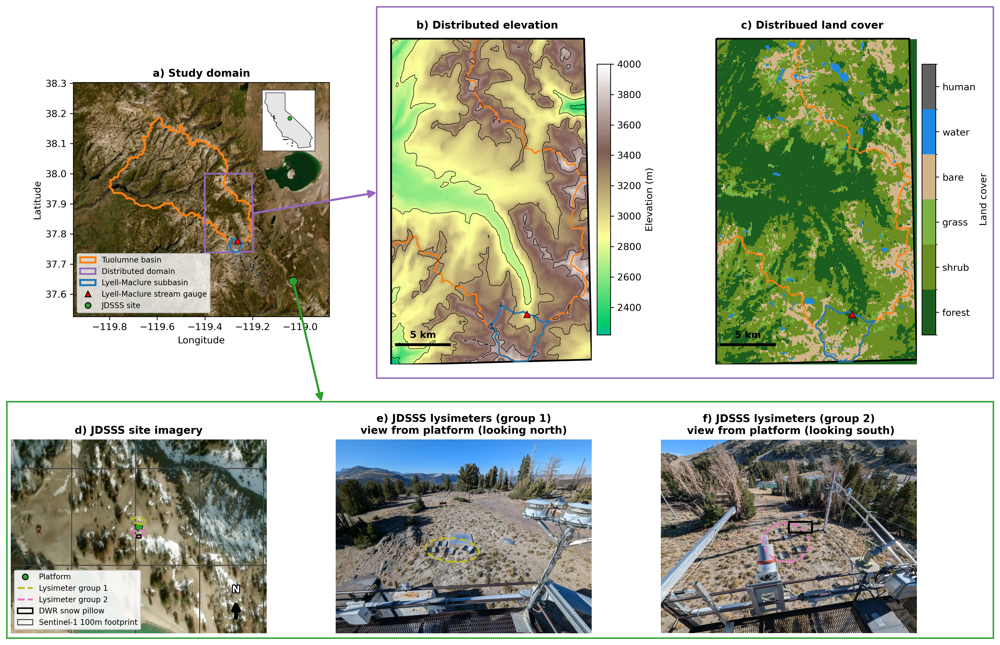

In [15]:
# -----------------------------
# Style choices
# -----------------------------
BASIN_COLOR = "C1"
AOI_COLOR   = "#00bfc4"
CUES_COLOR  = "C2"

LW_BASIN   = 2.0
LW_AOI     = 1.8
LW_OUTLINE = 1.6

TITLE_FS = 11
BOX_LW   = 1.5
ARROW_LW = 2.2

# TOP_GROUP_COLOR    = AOI_COLOR
TOP_GROUP_COLOR    = "C4"
# BOTTOM_GROUP_COLOR = CUES_COLOR
BOTTOM_GROUP_COLOR = "C2"
# HIGHLIGHT1_COLOR   = "#e7a3ff"   # pink/purple
# HIGHLIGHT2_COLOR   = "#ff8c4d"   # orange
HIGHLIGHT1_COLOR   = "C8"   # pink/purple
HIGHLIGHT2_COLOR   = "C6"   # orange

# -----------------------------
# Figure / layout
# -----------------------------
fig = plt.figure(figsize=(14, 10), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

# =========================================================
# (a) Study domain
# =========================================================
uscatm_geog_gdf.plot(ax=ax1, color="none", edgecolor=BASIN_COLOR, linewidth=LW_BASIN)
# uscatm_geog_gdf.plot(ax=ax1, color="none", edgecolor=TOP_GROUP_COLOR, linewidth=LW_BASIN)
tuolumne_geog_gdf.plot(ax=ax1, color="none", edgecolor=TOP_GROUP_COLOR, linewidth=LW_AOI)
lyell_gdf_proj.to_crs('EPSG:4326').plot(ax=ax1,color = "none",edgecolor = 'C0',linewidth=LW_AOI,linestyle = '-')

ax1.scatter(
    cues_lon, cues_lat,
    s=80, color=CUES_COLOR, edgecolor="k", linewidth=0.6, zorder=6
)
ax1.scatter(
    lyell_blw_maclure_gauge_lon_lat[0], lyell_blw_maclure_gauge_lon_lat[1],
    s=50, color='red', edgecolor="k", marker = '^', linewidth=0.6, zorder=6
)

_deg_lat = 10 / 111.32
_deg_lon = 10 / (111.32 * np.cos(np.radians(cues_lat)))
x0, x1 = ax1.get_xlim()
y0, y1 = ax1.get_ylim()
ax1.set_xlim(x0 - _deg_lon, x1 + _deg_lon)
ax1.set_ylim(y0 - _deg_lat, y1 + _deg_lat)

ctx.add_basemap(
    ax=ax1,
    crs="EPSG:4326",
    source=ctx.providers.Esri.WorldImagery,
    attribution=False
)

ax1.set_title("a) Study domain", fontweight="bold", fontsize=TITLE_FS)
ax1.set_ylabel("Latitude")
ax1.set_xlabel("Longitude")
ax1.tick_params(axis="x", labelrotation=0)

inset_ax = inset_axes(ax1, width="26%", height="26%", loc="upper right", borderpad=0.8)
ca_gdf.to_crs("EPSG:4326").plot(ax=inset_ax, color="0.9", edgecolor="0.2", linewidth=0.6)
inset_ax.scatter(cues_lon, cues_lat, s=18, color=CUES_COLOR, edgecolor="k", linewidth=0.4, zorder=5)
inset_ax.set_xticks([])
inset_ax.set_yticks([])
for spine in inset_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.6)
    spine.set_edgecolor("0.2")

legend_elements = [
    Patch(facecolor="none", edgecolor=BASIN_COLOR, linewidth=LW_BASIN, label="Tuolumne basin"),
    # Patch(facecolor="none", edgecolor=AOI_COLOR, linewidth=LW_AOI, label="Distributed Domain"),
    Patch(facecolor="none", edgecolor=TOP_GROUP_COLOR, linewidth=LW_AOI, label="Distributed domain"),
    Patch(facecolor="none", edgecolor='C0', linewidth=LW_BASIN,linestyle = '-', label="Lyell-Maclure subbasin"),
    Line2D([0], [0], marker="^", color="none", label="Lyell-Maclure stream gauge",
           markerfacecolor='red', markeredgecolor="k", markersize=6),
    Line2D([0], [0], marker="o", color="none", label="JDSSS site",
           markerfacecolor=CUES_COLOR, markeredgecolor="k", markersize=6),
]
ax1.legend(handles=legend_elements, loc="lower left", frameon=True, fontsize=8)

# =========================================================
# (b) Elevation
# =========================================================
cmap_custom = terrain_no_blue()
hgtPlot = hgt_proj_da.rio.clip(tuolumne_proj_gdf.geometry).rio.reproject("EPSG:4326")

p = hgtPlot.where(hgtPlot < 10000).plot(
    ax=ax2, vmax=4000, cmap=cmap_custom,
    cbar_kwargs={"shrink": 0.82, "pad": 0.02}
)
p.colorbar.set_label("Elevation (m)")

ax2.contour(
    hgtPlot.x.values, hgtPlot.y.values,
    hgtPlot.where(hgtPlot < 10000).values,
    levels=[2400, 2800, 3200, 3600, 4000],
    colors="black", linewidths=0.5, linestyles="solid"
)

uscatm_geog_gdf.clip(tuolumne_geog_gdf.geometry).plot(ax=ax2, color="none", edgecolor=BASIN_COLOR, linewidth=1.5)
tuolumne_geog_gdf.plot(ax=ax2, color="none", edgecolor="black", linewidth=LW_AOI)
lyell_gdf_proj.to_crs('EPSG:4326').plot(ax=ax2,color = "none",edgecolor = 'C0',linewidth=1.5)
ax2.scatter(
    lyell_blw_maclure_gauge_lon_lat[0], lyell_blw_maclure_gauge_lon_lat[1],
    s=50, color='red', edgecolor="k", marker = '^', linewidth=0.6, zorder=6
)

ax2.axis("off")
ax2.set_title("b) Distributed elevation", fontweight="bold", fontsize=TITLE_FS)

xlim_bc = ax2.get_xlim()
ylim_bc = ax2.get_ylim()

geod = Geod(ellps="WGS84")

scale_km = 5
scale_m = scale_km * 1000

xmin, xmax = ax2.get_xlim()
ymin, ymax = ax2.get_ylim()

# place scale bar near lower left
x0 = xmin + 0.06 * (xmax - xmin)
y0 = ymin + 0.06 * (ymax - ymin)

# find lon endpoint 10 km east from x0/y0
x1, y1, _ = geod.fwd(x0, y0, az=90, dist=scale_m)

ax2.plot([x0, x1], [y0, y1], color="black", lw=3, solid_capstyle="butt")

ax2.text(
    (x0 + x1) / 2,
    y0 + 0.015 * (ymax - ymin),
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

# =========================================================
# (c) Land cover
# =========================================================
im = (
    veg_proj_ds["veg_bin"]
    .rio.reproject("EPSG:4326")
    .rio.clip(tuolumne_geog_gdf.geometry)
    .plot(ax=ax3, cmap=cmap, norm=norm, add_colorbar=False)
)

uscatm_geog_gdf.clip(tuolumne_geog_gdf.geometry).plot(ax=ax3, color="none", edgecolor=BASIN_COLOR, linewidth=1.5)
tuolumne_geog_gdf.plot(ax=ax3, color="none", edgecolor="black", linewidth=LW_AOI)
lyell_gdf_proj.to_crs('EPSG:4326').plot(ax=ax3,color = "none",edgecolor = 'C0',linewidth=1.5)
ax3.scatter(
    lyell_blw_maclure_gauge_lon_lat[0], lyell_blw_maclure_gauge_lon_lat[1],
    s=50, color='red', edgecolor="k", marker = '^', linewidth=0.6, zorder=6
)

ax3.set_xlim(xlim_bc)
ax3.set_ylim(ylim_bc)

cbar = fig.colorbar(im, ax=ax3, ticks=codes, spacing="uniform", shrink=0.82, pad=0.02)
cbar.ax.set_yticklabels([veg_labels[c] for c in codes])
cbar.set_label("Land cover")

ax3.set_title("c) Distribued land cover", fontweight="bold", fontsize=TITLE_FS)
ax3.axis("off")

ax3.plot([x0, x1], [y0, y1], color="black", lw=3, solid_capstyle="butt")

ax3.text(
    (x0 + x1) / 2,
    y0 + 0.015 * (ymax - ymin),
    f"{scale_km} km",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

# =========================================================
# (d) CUES site imagery
# =========================================================
fp_slice = cues_footprint.bscatter.isel(time=0, band=0)
fp_4326 = fp_slice.rio.write_crs("EPSG:32611").rio.reproject("EPSG:4326")

pixel_size_x = float(abs(fp_4326.x[1] - fp_4326.x[0]))
pixel_size_y = float(abs(fp_4326.y[1] - fp_4326.y[0]))
d_xlim = (cues_lon - 2 * pixel_size_x, cues_lon + 2 * pixel_size_x)
d_ylim = (cues_lat - 1 * pixel_size_y, cues_lat + 1 * pixel_size_y)

ax4.set_xlim(*d_xlim)
ax4.set_ylim(*d_ylim)

ctx.add_basemap(
    ax=ax4,
    crs="EPSG:4326",
    source=ctx.providers.Esri.WorldImagery,
    attribution=False
)

ax4.set_aspect('auto')
ax4.set_xlim(*d_xlim)
ax4.set_ylim(*d_ylim)

photo_h, photo_w = lys_group1.shape[:2]
ax4.set_box_aspect(photo_h / photo_w)

# Sentinel pixel grid — dashed rectangles (pcolormesh does not support linestyle)
from matplotlib.patches import Rectangle as _Rect
from matplotlib.collections import PatchCollection
_mask_x = (fp_4326.x.values >= d_xlim[0] - pixel_size_x) & (fp_4326.x.values <= d_xlim[1] + pixel_size_x)
_mask_y = (fp_4326.y.values >= d_ylim[0] - pixel_size_y) & (fp_4326.y.values <= d_ylim[1] + pixel_size_y)
_patches = [
    _Rect((xi - pixel_size_x / 2, yi - pixel_size_y / 2), pixel_size_x, pixel_size_y)
    for xi in fp_4326.x.values[_mask_x]
    for yi in fp_4326.y.values[_mask_y]
]
ax4.add_collection(PatchCollection(
    _patches, facecolor='none', edgecolor='#444444',
    linewidth=1.0, linestyle='-', zorder=5
))
# ax4.scatter(-119.0291,37.6431,color = 'red')
ax4.scatter(-119.0291,37.6431,
            s=60, color=CUES_COLOR, edgecolor="k", linewidth=0.6, zorder=6)


ax4.axis("off")
ax4.set_title("d) JDSSS site imagery", fontweight="bold", fontsize=TITLE_FS)

dx = (ax4.get_xlim()[1] - ax4.get_xlim()[0]) * 0.016
dy = (ax4.get_ylim()[1] - ax4.get_ylim()[0]) * 0.016
site_square = Rectangle(
    (cues_lon - dx/2, cues_lat - dy/2), dx, dy,
    fill=False, edgecolor="k", linewidth=1.3, zorder=8
)


ax4.add_patch(Ellipse(
    (0.5, 0.58), 0.060, 0.028, angle=-18, transform=ax4.transAxes,
    fill=False, edgecolor=HIGHLIGHT1_COLOR, linewidth=2.0, linestyle="--", zorder=8
))
ax4.add_patch(Ellipse(
    (0.50, 0.517), 0.064, 0.028, angle=5, transform=ax4.transAxes,
    fill=False, edgecolor=HIGHLIGHT2_COLOR, linewidth=2.0, linestyle="--", zorder=8
))
ax4.add_patch(site_square)

legend_elements_d = [
    Line2D([0], [0], marker="o", color="none", label="Platform",
           markerfacecolor=CUES_COLOR, markeredgecolor="k", markersize=6),
    Line2D([0], [0], color=HIGHLIGHT1_COLOR, linestyle='--', linewidth=2, label='Lysimeter group 1'),
    Line2D([0], [0], color=HIGHLIGHT2_COLOR, linestyle='--', linewidth=2, label='Lysimeter group 2'),
    Patch(facecolor='none', edgecolor='black', linewidth=1.5, label='DWR snow pillow'),
    Patch(facecolor='none', edgecolor='#444444', linewidth=1.0, linestyle = '-', label='Sentinel-1 100m footprint'),
]
ax4.legend(handles=legend_elements_d, loc='lower left', fontsize=8, frameon=True, framealpha=0.9)

# North arrow — bottom-right corner of panel d)
ax4.annotate('', xy=(0.88, 0.18), xytext=(0.88, 0.07),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='-|>', color='black', lw=4.0,
                             mutation_scale=16))
ax4.text(0.88, 0.20, 'N', transform=ax4.transAxes,
         ha='center', va='bottom', fontsize=10, fontweight='bold',
         color='white', path_effects=[
             __import__('matplotlib.patheffects', fromlist=['withStroke'])
             .withStroke(linewidth=2, foreground='black')])

# =========================================================
# (e) Lysimeter group 1
# =========================================================
ax5.imshow(lys_group1)
ax5.axis("off")
ax5.set_title("e) JDSSS lysimeters (group 1)\nview from platform (looking north)", fontweight="bold", fontsize=TITLE_FS)

for spine in ax5.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("0.3")

ax5.add_patch(Ellipse(
    (0.455, 0.43), 0.21, 0.12, angle=-8, transform=ax5.transAxes,
    fill=False, edgecolor=HIGHLIGHT1_COLOR, linewidth=2.0, linestyle="--", zorder=6
))

# =========================================================
# (f) Lysimeter group 2
# =========================================================
ax6.imshow(lys_group2)
ax6.axis("off")
ax6.set_title("f) JDSSS lysimeters (group 2)\n view from platform (looking south)", fontweight="bold", fontsize=TITLE_FS)

for spine in ax6.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("0.3")

ax6.add_patch(Ellipse(
    (0.49, 0.47), 0.18, 0.20, angle=8, transform=ax6.transAxes,
    fill=False, edgecolor=HIGHLIGHT2_COLOR, linewidth=2.0, linestyle="--", zorder=6
))

ax6.add_patch(Rectangle(
    (0.5, 0.52), 0.09, 0.055, transform=ax6.transAxes,
    fill=False, edgecolor='black', linewidth=2.0, zorder=7
))

# =========================================================
# Equal spacing: reposition ax4 so gap(d→e) == gap(e→f)
# Disable constrained_layout after so plt.show() doesn't undo it.
# =========================================================
fig.canvas.draw()

ax5_pos = ax5.get_position()
ax6_pos = ax6.get_position()
ax4_pos = ax4.get_position()

ef_gap = ax6_pos.x0 - ax5_pos.x1
new_x0 = ax5_pos.x0 - ef_gap - ax4_pos.width
ax4.set_position([new_x0, ax4_pos.y0, ax4_pos.width, ax4_pos.height])

fig.set_constrained_layout(False)

# =========================================================
# Group boxes — titles included (pad_top=0.040)
# Top box also extended right past colorbar label
# =========================================================
ax2_pos  = ax2.get_position()
ax3_pos  = ax3.get_position()
ax4_pos  = ax4.get_position()   # updated position
cbar_pos = cbar.ax.get_position()

top_left    = ax2_pos.x0 - 0.006
bottom_left = ax4_pos.x0 - 0.004
top_right    = cbar_pos.x1 + 0.060   # extend past colorbar + label
bottom_right = top_right              # align both boxes' right edges

def add_group_box(fig, axes, color,
                  pad_left=0.01, pad_right=0.01,
                  pad_bottom=0.015, pad_top=0.005,
                  lw=1.5, x0_override=None, x1_override=None,
                  y0_override=None, y1_override=None, y_offset=0.0):
    positions = [ax.get_position() for ax in axes]
    x0 = min(p.x0 for p in positions) - pad_left
    y0 = min(p.y0 for p in positions) - pad_bottom + y_offset
    x1 = max(p.x1 for p in positions) + pad_right
    y1 = max(p.y1 for p in positions) + pad_top + y_offset
    if x0_override is not None: x0 = x0_override
    if x1_override is not None: x1 = x1_override
    if y0_override is not None: y0 = y0_override
    if y1_override is not None: y1 = y1_override
    rect = Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        transform=fig.transFigure,
        fill=False, edgecolor=color, linewidth=lw, zorder=20
    )
    fig.add_artist(rect)
    return (x0, y0, x1, y1)

top_box = add_group_box(
    fig, [ax2, ax3], color=TOP_GROUP_COLOR,
    pad_left=0.010, pad_right=0.000, pad_bottom=0.020, pad_top=0.040,
    lw=BOX_LW, x0_override=top_left, x1_override=top_right
)

bottom_box = add_group_box(
    fig, [ax4, ax5, ax6], color=BOTTOM_GROUP_COLOR,
    pad_left=0.014, pad_right=0.014, pad_bottom=0.022, pad_top=0.040, y_offset=0.015,
    lw=BOX_LW, x0_override=bottom_left, x1_override=bottom_right
)

# =========================================================
# Connector arrows
# =========================================================
aoi_bounds = tuolumne_geog_gdf.to_crs("EPSG:4326").total_bounds
aoi_start_x = aoi_bounds[2]
aoi_start_y = 0.50 * (aoi_bounds[1] + aoi_bounds[3])

con_top = ConnectionPatch(
    xyA=(aoi_start_x, aoi_start_y), coordsA=ax1.transData,
    xyB=(top_box[0], 0.50 * (top_box[1] + top_box[3])), coordsB=fig.transFigure,
    arrowstyle="-|>", mutation_scale=16, linewidth=ARROW_LW, color=TOP_GROUP_COLOR, zorder=21
)
fig.add_artist(con_top)

con_bottom = ConnectionPatch(
    xyA=(cues_lon, cues_lat), coordsA=ax1.transData,
    xyB=(ax5_pos.x0 - 0.015, bottom_box[3]), coordsB=fig.transFigure,
    arrowstyle="-|>", mutation_scale=16, linewidth=ARROW_LW, color=BOTTOM_GROUP_COLOR, zorder=21
)
fig.add_artist(con_bottom)

# =========================================================
# Save / show
# =========================================================
plt.savefig("./pngs/F02_domains.png", dpi=300, bbox_inches="tight")
plt.show()